In [46]:
import random
import numpy as np
import torch
from skimage import data

im = data.astronaut()
im = np.swapaxes(np.swapaxes(im, 0, 2), 1, 2)
im = torch.from_numpy(im)
nbin = random.randint(32,128)


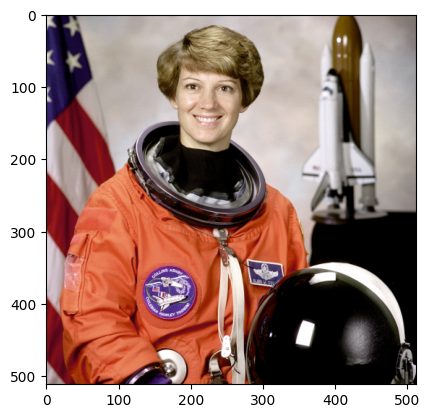

In [47]:
import matplotlib.pyplot as plt

plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

In [48]:
im.shape

torch.Size([3, 512, 512])

In [49]:
nbin

95

In [56]:
im = (im * float(nbin) // 256)

In [ ]:
im = (im * float(nbin) // 256)

hists = []
    
for i in range(3):
    hist = torch.zeros((nbin, ))
    for b in range(nbin):
        hist[b] = torch.sum(im[i] == b)
    
    hists.append(hist)

out = torch.cat(hists)
out = out / out.sum()

In [58]:
torch.sum(out)

tensor(1.)

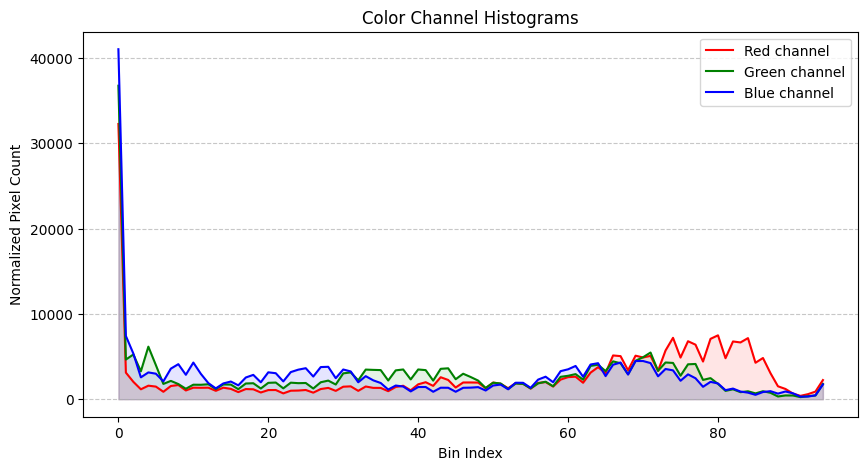

In [59]:
import matplotlib.pyplot as plt

colors = ('red', 'green', 'blue')
plt.figure(figsize=(10, 5))

for i, col in enumerate(colors):
    hdata = hists[i].numpy()
    
    bins = range(len(hdata))
    
    plt.plot(bins, hdata, color=col, label=f'{col.capitalize()} channel')
    plt.fill_between(bins, hdata, color=col, alpha=0.1)

plt.title("Color Channel Histograms")
plt.xlabel("Bin Index")
plt.ylabel("Normalized Pixel Count")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()